In [63]:
# --- CELL 1: ENVIRONMENT & INGESTION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Set visual style for EDA
sns.set_theme(style="whitegrid")

print("Step 1: Loading raw Pipeline ILI datasets...")

# Load the raw CSV files
df_2015 = pd.read_csv('V-T ILI 2015 - Copy - Sheet1.csv', low_memory=False)
df_2023 = pd.read_csv('V-T_ILI_2023_Cleaned.csv', low_memory=False)

# Clean up column names by stripping accidental whitespace
df_2015.columns = df_2015.columns.str.strip()
df_2023.columns = df_2023.columns.str.strip()

print(f"✅ 2015 Data Loaded: {len(df_2015):,} rows found.")
print(f"✅ 2023 Data Loaded: {len(df_2023):,} rows found.")

Step 1: Loading raw Pipeline ILI datasets...
✅ 2015 Data Loaded: 14,691 rows found.
✅ 2023 Data Loaded: 31,421 rows found.


In [64]:
# ==========================================
# ZEROING THE ODOMETER (Normalizing Distances)
# ==========================================

print("--- Zeroing 2015 Dataset ---")
# 1. Grab the exact distance of the very first row (the ~56m valve)
start_dist_15 = df_2015['Pigrun log distance (m)'].iloc[0]
print(f"Original 2015 start distance: {start_dist_15} m")

# 2. Subtract this value from the entire column at once
df_2015['Pigrun log distance (m)'] = df_2015['Pigrun log distance (m)'] - start_dist_15


print("--- Zeroing 2023 Dataset ---")
# 1. Grab the exact distance of the very first row (the ~56m valve)
start_dist_23 = df_2023['Pigrun log distance (m)'].iloc[0]
print(f"Original 2023 start distance: {start_dist_23} m")

# 2. Subtract this value from the entire column at once
df_2023['Pigrun log distance (m)'] = df_2023['Pigrun log distance (m)'] - start_dist_23


--- Zeroing 2015 Dataset ---
Original 2015 start distance: 57.415 m
--- Zeroing 2023 Dataset ---
Original 2023 start distance: 56.431 m


In [65]:
# Columns to keep
cols_to_keep = [
    'Length (mm)',
    'Width (mm)',
    'Depth (mm)',
    'Up weld dist (m)',
    'Clock (hh:mm)',
    'Pigrun log distance (m)',
    'Feature type',
    'Feature identification'
]

# Keep only these columns
df_2023 = df_2023[cols_to_keep]

In [66]:
# In Feature type column keep only Anomaly and in Feature Identification column keep only Metal loss
df_Anomaly23 = df_2023[df_2023['Feature type'].isin(['Anomaly']) & df_2023['Feature identification'].isin(['Metal loss'])]

In [67]:
# Columns to keep
cols_to_keep = [
    'Length (mm)',
    'Width (mm)',
    'Depth (mm)',
    'Up weld dist (m)',
    'Clock (hh:mm)',
    'Pigrun log distance (m)',
    'Feature type',
    'Feature identification',
    
]

# Keep only these columns
df_2015 = df_2015[cols_to_keep]


In [68]:
# In Feature type column keep only Anomaly and in Feature Identification column keep only Metal loss
df_Anomaly15 = df_2015[df_2015['Feature type'].isin(['Anomaly']) & df_2015['Feature identification'].isin(['Anomaly'])]

In [69]:
df_Anomaly15.shape

(8898, 8)

In [70]:
df_Anomaly23.shape

(25064, 8)

In [71]:
## Helper function to convert "HH:MM" strings into a 360-degree mathematical angle
def clock_to_degrees(clock_str):
    
    parts = str(clock_str).split(':')
    hours = float(parts[0])
    minutes = float(parts[1])
    # 1 hour = 30 degrees, 1 minute = 0.5 degrees
    degrees = (hours * 30.0) + (minutes * 0.5)
    return degrees 

# Create safe copies of the data and apply the mathematical conversion
df_Anomaly15 = df_Anomaly15.copy()
df_Anomaly23 = df_Anomaly23.copy()

df_Anomaly15['Angle_Deg'] = df_Anomaly15['Clock (hh:mm)'].apply(clock_to_degrees)
df_Anomaly23['Angle_Deg'] = df_Anomaly23['Clock (hh:mm)'].apply(clock_to_degrees)

In [72]:
# ==========================================
# 2. FILTER FOR THE SAFE ZONE
# ==========================================
print("Filtering for anomalies in the aligned zone...\n")

safe_anomalies_15 = df_Anomaly15[df_Anomaly15['Pigrun log distance (m)'] <= 7315]
safe_anomalies_23 = df_Anomaly23[df_Anomaly23['Pigrun log distance (m)'] <= 7340]

Filtering for anomalies in the aligned zone...



In [73]:
safe_anomalies_23 = safe_anomalies_23.reset_index()
safe_anomalies_15 = safe_anomalies_15.reset_index()

In [74]:
safe_anomalies_15

,index,Length (mm),Width (mm),Depth (mm),Up weld dist (m),Clock (hh:mm),Pigrun log distance (m),Feature type,Feature identification,Angle_Deg
0,4,28.0,25.0,0.857,5.058,01:00,10.251,Anomaly,Anomaly,30.0
1,6,41.0,41.0,0.857,3.414,11:40,14.152,Anomaly,Anomaly,350.0
2,7,40.0,36.0,0.714,5.367,00:20,16.105,Anomaly,Anomaly,10.0
3,8,48.0,69.0,1.142,5.398,11:30,16.136,Anomaly,Anomaly,345.0
4,10,23.0,28.0,0.785,6.004,10:30,28.770,Anomaly,Anomaly,315.0
...,...,...,...,...,...,...,...,...,...,...
1769,2690,30.0,23.0,0.857,5.301,06:20,7307.338,Anomaly,Anomaly,190.0
1770,2691,23.0,28.0,0.857,10.398,02:30,7312.435,Anomaly,Anomaly,75.0
1771,2692,15.0,23.0,0.857,10.945,02:25,7312.982,Anomaly,Anomaly,72.5
1772,2693,0.0,0.0,0.000,11.195,10:20,7313.232,Anomaly,Anomaly,310.0


In [75]:
print("Step 1: Extracting Welds to build the Spool Map...")

# 1. Get the Weld Distances for the Safe Zone (0 - 7.3km)
# We pull this from the raw dataframes you loaded in Cell 1
welds_15 = df_2015[(df_2015['Feature type'].str.contains('Weld', na=False)) & (df_2015['Pigrun log distance (m)'] <= 7315)]
welds_23 = df_2023[(df_2023['Feature type'].str.contains('Weld', na=False)) & (df_2023['Pigrun log distance (m)'] <= 7340)]

# Create arrays of the physical weld locations
weld_dists_15 = welds_15['Pigrun log distance (m)'].sort_values().values
weld_dists_23 = welds_23['Pigrun log distance (m)'].sort_values().values

print(f"Found {len(weld_dists_15)} Welds in 2015 (Safe Zone)")
print(f"Found {len(weld_dists_23)} Welds in 2023 (Safe Zone)")

Step 1: Extracting Welds to build the Spool Map...
Found 679 Welds in 2015 (Safe Zone)
Found 679 Welds in 2023 (Safe Zone)


In [76]:
# ==========================================
# Step 2: Assign a "Spool ID" to every anomaly
# ==========================================
print("\nStep 2: Assigning Spool IDs to all anomalies...")

# np.searchsorted finds which two welds an anomaly sits between.
# E.g., if Welds are at 0m, 12m, 24m, an anomaly at 15m gets assigned to Spool #2.
safe_anomalies_15 = safe_anomalies_15.copy()
safe_anomalies_23 = safe_anomalies_23.copy()

safe_anomalies_15['Spool_ID'] = np.searchsorted(weld_dists_15, safe_anomalies_15['Pigrun log distance (m)'])
safe_anomalies_23['Spool_ID'] = np.searchsorted(weld_dists_23, safe_anomalies_23['Pigrun log distance (m)'])


Step 2: Assigning Spool IDs to all anomalies...


Step 1: Gathering all possible candidates inside each Spool...
✅ Gathered 53,721 possible pairings. Running tests...

Step 2: Testing combinations of Distance and Angle tolerances...


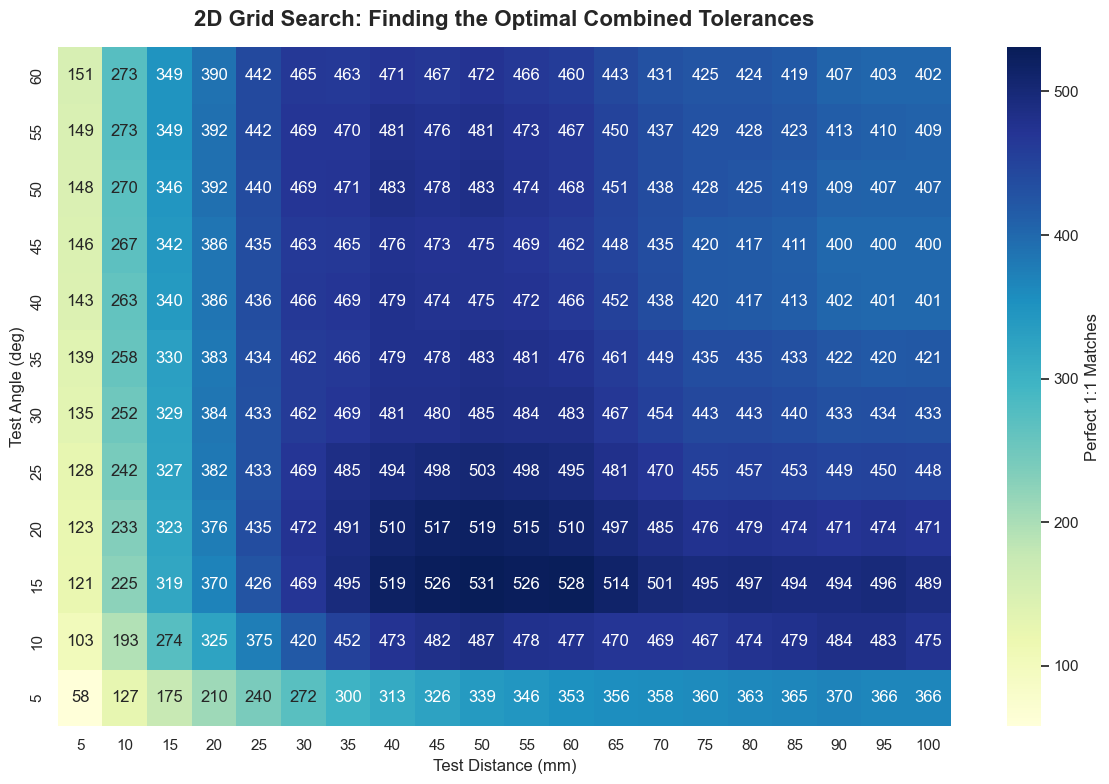


🏆 ALGORITHMIC CONCLUSION:
The absolute optimal combination is 50mm Distance & 15° Clock Angle.
This yields 531 perfect, scientifically safe matches.


In [88]:
# --- CELL: SIMPLIFIED 2D GRID SEARCH (PIVOT METHOD) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1: Gathering all possible candidates inside each Spool...")

# Give every anomaly a unique ID
safe_anomalies_15 = safe_anomalies_15.copy()
safe_anomalies_15['UID_15'] = range(len(safe_anomalies_15))

all_possible_pairs = []

# ------------------------------------------------------------------------- 
# Step 1 looks inside every individual pipe (Spool). It takes a 2015 anomaly 
# and calculates its exact distance and angle error compared to every 2023 
# anomaly in that same pipe. It saves these errors to a master list.
# -------------------------------------------------------------------------

for index, a15 in safe_anomalies_15.iterrows():
    # Only look at 2023 anomalies in the exact same Spool
    candidates = safe_anomalies_23[safe_anomalies_23['Spool_ID'] == a15['Spool_ID']]
    
    for _, c23 in candidates.iterrows():
        # Calculate Distance Error
        dist_error = np.abs(c23['Up weld dist (m)'] - a15['Up weld dist (m)'])
        
        # Calculate Angle Error (Handling the 360-degree circle)
        raw_angle = np.abs(c23['Angle_Deg'] - a15['Angle_Deg'])
        angle_error = np.minimum(raw_angle, 360.0 - raw_angle)
        
        # Save the pair's errors
        all_possible_pairs.append({
            'UID_15': a15['UID_15'],
            'Distance_Error_m': dist_error,
            'Angle_Error_deg': angle_error
        })

df_pairs = pd.DataFrame(all_possible_pairs)
print(f"✅ Gathered {len(df_pairs):,} possible pairings. Running tests...")
 
# ==========================================
# Step 2: The Grid Search (Simple Loop)
# ==========================================
print("\nStep 2: Testing combinations of Distance and Angle tolerances...")
test_results = []

# Test distances from 5mm to 100mm (Steps of 5)
for test_dist_mm in range(5, 105, 5):
    
    # Test angles from 5° to 60° (Steps of 5)
    for test_angle_deg in range(5, 65, 5):
        
        # 1. Keep only the pairs that pass BOTH of these specific test limits
        passed = df_pairs[(df_pairs['Distance_Error_m'] <= (test_dist_mm / 1000.0)) & 
                          (df_pairs['Angle_Error_deg'] <= test_angle_deg)]
        
        # 2. Count how many matches each 2015 anomaly found
        match_counts = passed['UID_15'].value_counts()
        
        # 3. We only want perfect 1:1 matches! (No clusters)
        perfect_matches = (match_counts == 1).sum()
        
        # Save this test result to our list
        test_results.append({
            'Test Distance (mm)': test_dist_mm,
            'Test Angle (deg)': test_angle_deg,
            'Perfect Matches': perfect_matches
        })

df_results = pd.DataFrame(test_results)

# ==========================================
# Step 3: Visualizing with a Pivot Table
# ==========================================
# -------------------------------------------------------------------------
# We take our list of test results and automatically "Pivot" it into a grid, 
# exactly like Microsoft Excel, so we can color-code it into a Heatmap.
# -------------------------------------------------------------------------

# Create the Grid
heatmap_grid = df_results.pivot(index='Test Angle (deg)', 
                                columns='Test Distance (mm)', 
                                values='Perfect Matches')

# Draw the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_grid, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Perfect 1:1 Matches'})

plt.title('2D Grid Search: Finding the Optimal Combined Tolerances', fontsize=16, fontweight='bold', pad=15)
plt.gca().invert_yaxis() # Put 10 degrees at the bottom
plt.tight_layout()
plt.show()

# Find the absolute best combination simply by sorting the flat list!
best_result = df_results.sort_values(by='Perfect Matches', ascending=False).iloc[0]
print(f"\n🏆 ALGORITHMIC CONCLUSION:")
print(f"The absolute optimal combination is {int(best_result['Test Distance (mm)'])}mm Distance & {int(best_result['Test Angle (deg)'])}° Clock Angle.")
print(f"This yields {int(best_result['Perfect Matches'])} perfect, scientifically safe matches.")